In [1]:
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

from plbregression.dataset import PLBDataset, RandomRotatedShiftedCrop, ResizeTo, HKLToUnitVector, ParamsNormalizer
from plbregression.noise import add_microscopic_noise, add_microscopic_noise_single

## 1. surowe zdjęcia

Image shape: (296, 296)
Params: [104.23471      0.30726284  22.          81.          18.        ]


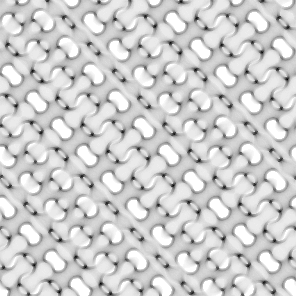

In [2]:
dataset_raw = PLBDataset(
    data_dir="../../data_generation/dataset_01_20260223", 
    indices=np.arange(100), 
    # transforms=[RandomRotatedShiftedCrop(size=150, interpolation="cubic")],
    # return_tensors=True
)

image, params = dataset_raw[0]
print("Image shape:", image.shape)
print("Params:", params)
Image.fromarray(image)

## 2. Wycięte zdjęcia

Image shape: (150, 150)
Params: [104.23471      0.30726284  22.          81.          18.        ]


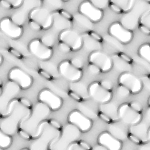

In [3]:
dataset_with_crop = PLBDataset(
    data_dir="../../data_generation/dataset_01_20260223", 
    indices=np.arange(100), 
    transforms=[RandomRotatedShiftedCrop(size=150, interpolation="cubic")],
    # return_tensors=True
)

image, params = dataset_with_crop[0]
print("Image shape:", image.shape)
print("Params:", params)
Image.fromarray(image)

## 3. Tensory

Image shape: torch.Size([1, 150, 150])
Params: tensor([104.2347,   0.3073,  22.0000,  81.0000,  18.0000])


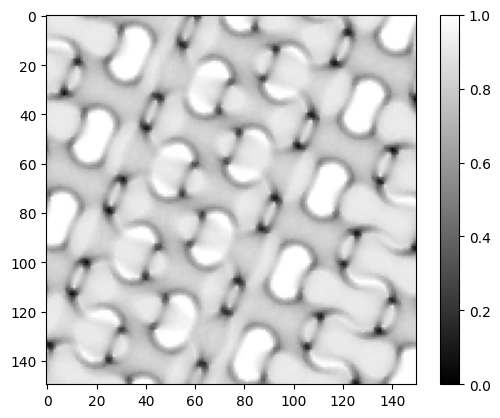

In [4]:
dataset_with_crop_tensor = PLBDataset(
    data_dir="../../data_generation/dataset_01_20260223", 
    indices=np.arange(100), 
    transforms=[RandomRotatedShiftedCrop(size=150, interpolation="cubic")],
    return_tensors=True
)

image, params = dataset_with_crop_tensor[0]
print("Image shape:", image.shape)
print("Params:", params)
plt.imshow(image[0], cmap="gray", vmin=0, vmax=1)
plt.colorbar()

## 4. Tensory powiększone do rozmiaru wejściowego sieci

Image shape: torch.Size([1, 224, 224])
Params: tensor([104.2347,   0.3073,  22.0000,  81.0000,  18.0000])


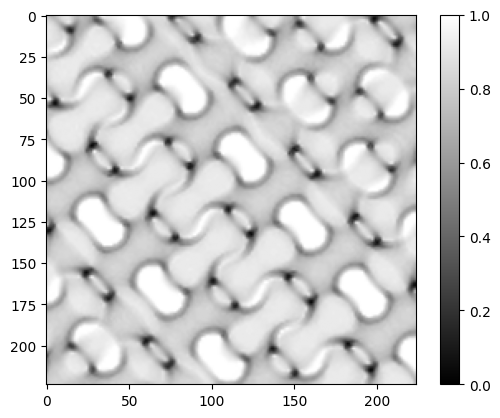

In [5]:
dataset_with_crop_tensor_resized = PLBDataset(
    data_dir="../../data_generation/dataset_01_20260223", 
    indices=np.arange(100), 
    transforms=[
        RandomRotatedShiftedCrop(size=150, interpolation="cubic"),
        ResizeTo(size=224, interpolation="cubic")
        ],
    return_tensors=True
)

image, params = dataset_with_crop_tensor_resized[0]
print("Image shape:", image.shape)
print("Params:", params)
plt.imshow(image[0], cmap="gray", vmin=0, vmax=1)
plt.colorbar()

## 5. Tylko część parametrów

Image shape: torch.Size([1, 224, 224])
Params: tensor([104.2347,   0.3073])


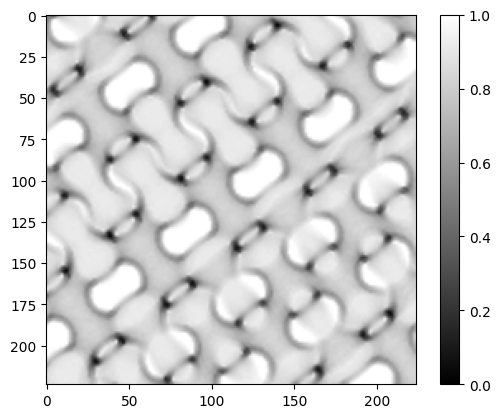

In [6]:
dataset_with_some_params = PLBDataset(
    data_dir="../../data_generation/dataset_01_20260223", 
    indices=np.arange(100), 
    transforms=[
        RandomRotatedShiftedCrop(size=150, interpolation="cubic"),
        ResizeTo(size=224, interpolation="cubic")
        ],
    return_tensors=True,
    use_params=['uc_scale_ab', 'channel_vol_prop']
)

image, params = dataset_with_some_params[0]
print("Image shape:", image.shape)
print("Params:", params)
plt.imshow(image[0], cmap="gray", vmin=0, vmax=1)
plt.colorbar()

## 6. Znormalizowane parametry

In [7]:
uc_scale_and_volum_prop_data = np.load("../../data_generation/dataset_01_20260223/params_0.npy", mmap_mode="r")[:,:2]
uc_scale_and_volum_prop_means = uc_scale_and_volum_prop_data.mean(axis=0)
uc_scale_and_volum_prop_stds = uc_scale_and_volum_prop_data.std(axis=0)

In [8]:
uc_scale_and_volum_prop_means, uc_scale_and_volum_prop_stds

(array([85.03442   ,  0.32531843], dtype=float32),
 array([20.201132  ,  0.10095225], dtype=float32))

Image shape: torch.Size([1, 224, 224])
Params: tensor([ 0.9505, -0.1789])
Unit vector: tensor([0.2097, 0.2563, 0.9436]) length: 1.0


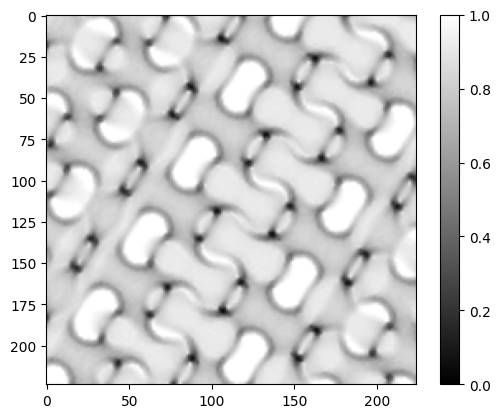

In [9]:
dataset_normalized = PLBDataset(
    data_dir="../../data_generation/dataset_01_20260223", 
    indices=np.arange(100), 
    transforms=[
        RandomRotatedShiftedCrop(size=150, interpolation="cubic"),
        ResizeTo(size=224, interpolation="cubic")
        ],
    return_tensors=True,
    params_transforms=[
        ParamsNormalizer(means=uc_scale_and_volum_prop_means, stds=uc_scale_and_volum_prop_stds, indices_to_use=(0,1)),
        HKLToUnitVector(indices_to_use=(2, 3, 4))
        
    ]
    # use_params=['uc_scale_ab', 'channel_vol_prop']
)

image, params = dataset_normalized[0]
print("Image shape:", image.shape)
print("Params:", params[:2])
print("Unit vector:", params[2:], "length:", np.linalg.norm(params[2:]))
plt.imshow(image[0], cmap="gray", vmin=0, vmax=1)
plt.colorbar()

## 7. Albumentation transforms (from `albumentationsx`)

In [10]:
import albumentations as A

from plbregression.dataset import AlbumentationImageTransformWrapper

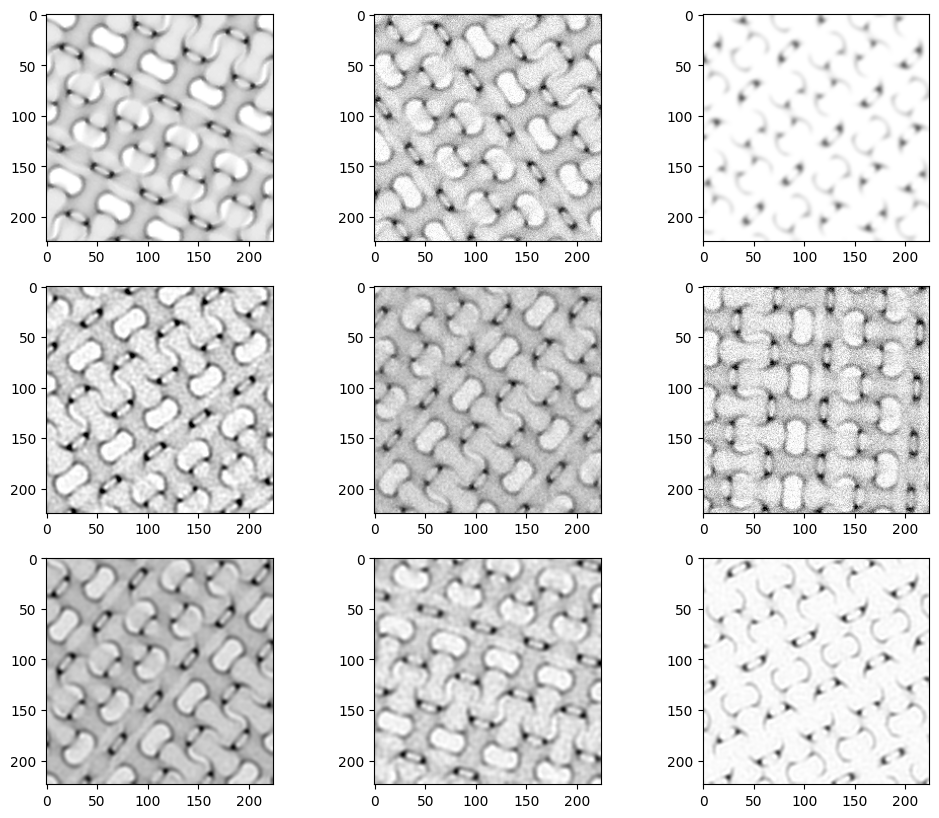

In [11]:
albumentation_transform = A.Compose([
    # A.SaltAndPepper(p=0.5),
    A.ShotNoise(scale_range=(0,0.05), p=0.5),
    A.AdvancedBlur(p=0.5),
    # A.Illumination(p=0.5),
    A.RandomBrightnessContrast(p=0.5),
    A.GaussNoise(std_range=(0.001, 0.05), noise_scale_factor=1, p=0.5),
    A.GaussNoise(std_range=(0.001, 0.05), noise_scale_factor=0.6, p=0.5), # noise_scale_factor<1 oznacza, że szum ma większą skalę długości niż 1 px
    A.RingingOvershoot(p=0.5),
])
# więcej na: https://albumentations.ai/docs/api-reference/albumentations/augmentations/pixel/transforms

dataset_with_albumentation_transform = PLBDataset(
    data_dir="../../data_generation/dataset_01_20260223", 
    indices=np.arange(100), 
    transforms=[
        RandomRotatedShiftedCrop(size=150, interpolation="cubic"),
        ResizeTo(size=224, interpolation="cubic"),
        AlbumentationImageTransformWrapper(albumentation_transform)
        ],
    return_tensors=True,
    params_transforms=[
        ParamsNormalizer(means=uc_scale_and_volum_prop_means, stds=uc_scale_and_volum_prop_stds, indices_to_use=(0,1)),
        HKLToUnitVector(indices_to_use=(2, 3, 4))
        
    ]
)


fig, axs = plt.subplots(3, 3, figsize=(12,10))
for i in range(9):
    i_row = i // 3
    i_col = i % 3
    image, params = dataset_with_albumentation_transform[0]
    # print("Image shape:", image.shape)
    # print("Params:", params[:2])
    # print("Unit vector:", params[2:], "length:", np.linalg.norm(params[2:]))
    axs[i_row][i_col].imshow(image[0], cmap="gray", vmin=0, vmax=1)
    # plt.colorbar()

## 8. Mikroskopowy szum

### 8.1 Jako funkcja

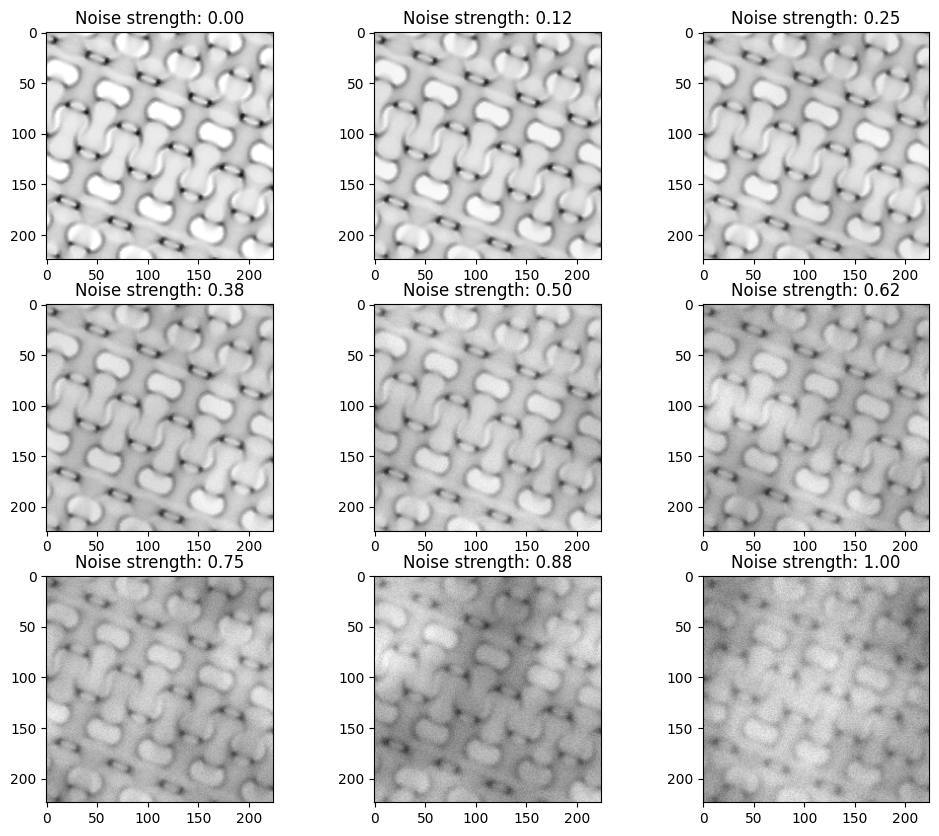

In [12]:
dataset = PLBDataset(
    data_dir="../../data_generation/dataset_01_20260223", 
    indices=np.arange(100), 
    transforms=[
        RandomRotatedShiftedCrop(size=150, interpolation="cubic"),
        ResizeTo(size=224, interpolation="cubic")
        ],
    return_tensors=False,
    params_transforms=[
        ParamsNormalizer(means=uc_scale_and_volum_prop_means, stds=uc_scale_and_volum_prop_stds, indices_to_use=(0,1)),
        HKLToUnitVector(indices_to_use=(2, 3, 4))
        
    ]
    # use_params=['uc_scale_ab', 'channel_vol_prop']
)
image_raw, params = dataset[0]
noise_strengths = np.linspace(0, 1, 9)
fig, axs = plt.subplots(3, 3, figsize=(12,10))
for i, noise_strength in enumerate(noise_strengths):
    i_row = i // 3
    i_col = i % 3
    image_noisy = add_microscopic_noise_single(image_raw, noise_strength)
    axs[i_row][i_col].imshow(image_noisy, cmap="gray", vmin=0, vmax=255)
    axs[i_row][i_col].set_title(f"Noise strength: {noise_strength:.2f}")


### 8.2 Jako transformacja w zbiorze danych

In [13]:
from plbregression.dataset import MicroscopicNoise, RandomMicroscopicNoise

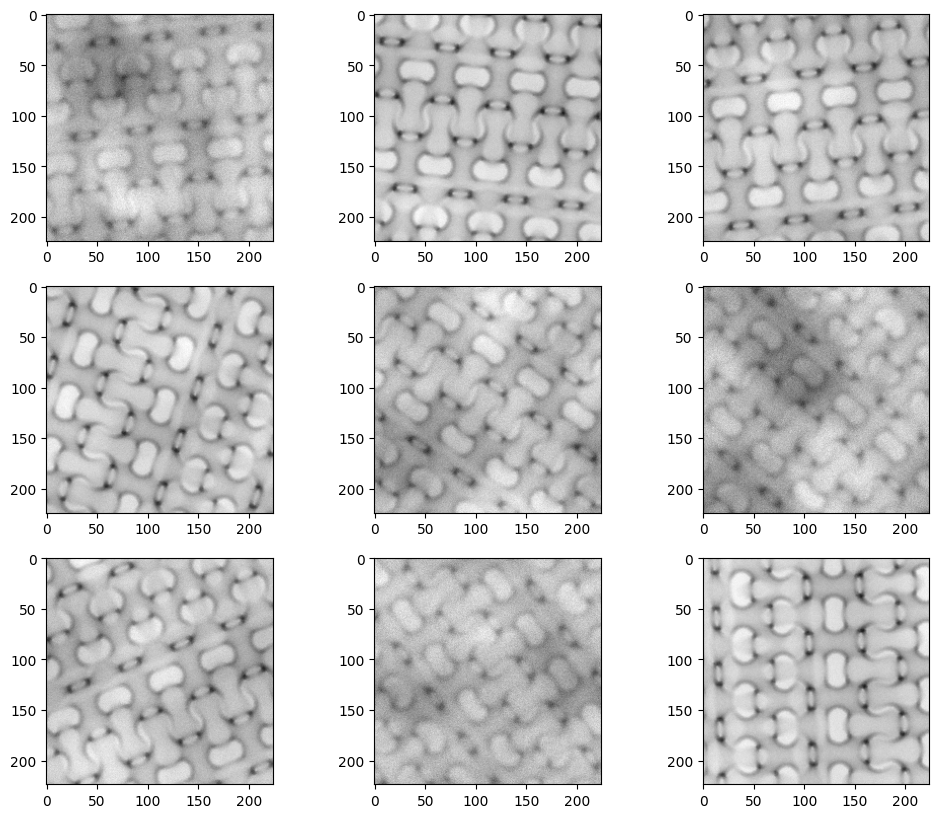

In [15]:
dataset_with_microscopic_noise = PLBDataset(
    data_dir="../../data_generation/dataset_01_20260223", 
    indices=np.arange(100), 
    transforms=[
        RandomRotatedShiftedCrop(size=150, interpolation="cubic"),
        ResizeTo(size=224, interpolation="cubic"),
        RandomMicroscopicNoise(strength_range=(0.3, 1))
        # AlbumentationImageTransformWrapper(albumentation_transform)
        ],
    return_tensors=True,
    params_transforms=[
        ParamsNormalizer(means=uc_scale_and_volum_prop_means, stds=uc_scale_and_volum_prop_stds, indices_to_use=(0,1)),
        HKLToUnitVector(indices_to_use=(2, 3, 4))
        
    ]
)

fig, axs = plt.subplots(3, 3, figsize=(12,10))
for i in range(9):
    i_row = i // 3
    i_col = i % 3
    image, params = dataset_with_microscopic_noise[0]
    # print("Image shape:", image.shape)
    # print("Params:", params[:2])
    # print("Unit vector:", params[2:], "length:", np.linalg.norm(params[2:]))
    axs[i_row][i_col].imshow(image[0], cmap="gray", vmin=0, vmax=1)
    # plt.colorbar()

## Debug

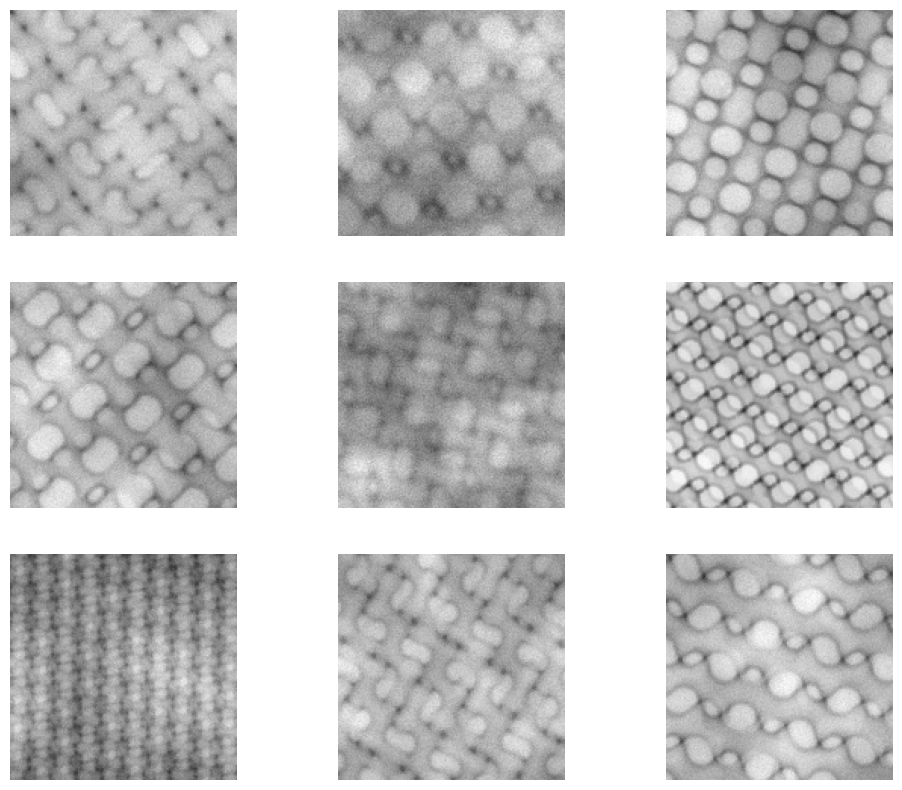

In [58]:
from omegaconf import OmegaConf
from hydra.utils import instantiate
import torch

dataset_config = OmegaConf.create({
    "_target_": "plbregression.dataset.PLBDataset",
    "data_dir": "../../data_generation/dataset_02_20260401_N10000",
    "indices": 1000, #1000
    "use_params": ['uc_scale_ab', 'channel_vol_prop', 'h', 'k', 'l'],
    "return_tensors": True,
    "params_transforms": [
        {
            "_target_": "plbregression.dataset.ParamsNormalizer",
            "means": [85.03442   ,  0.32531843],
            "stds": [20.201132  ,  0.10095225],
            "indices_to_use": (0,1)
        },
        {
            "_target_": "plbregression.dataset.HKLToUnitVector",
            "indices_to_use": (2, 3, 4)
        }
    ],
    "transforms": [
        {
            "_target_": "plbregression.dataset.RandomRotatedShiftedCrop",
            "size": 150,
            "interpolation": "cubic"
        },
        {
            "_target_": "plbregression.dataset.RandomMicroscopicNoise",
            "strength_range": (0, 1.0)
        },
    ],
})

dataset = instantiate(dataset_config)
dataloader = torch.utils.data.DataLoader(dataset, batch_size=9, shuffle=False)
images, params = next(iter(dataloader))

fig, axs = plt.subplots(3, 3, figsize=(12,10))
for i in range(9):
    i_row = i // 3
    i_col = i % 3
    axs[i_row][i_col].imshow(images[i][0], cmap="gray", vmin=0, vmax=1)
    axs[i_row][i_col].set_axis_off()
